In [240]:
import pandas as pd

# Carregar o arquivo CSV
df = pd.read_csv('base.csv')
# Remover as colunas indesejadas
df = df.drop(columns=['product_id','seller_id','product_name_lenght','product_description_lenght','product_photos_qty','product_category_name_english','customer_id','customer_unique_id','payment_sequential','payment_type','payment_installments','review_id','review_score','review_comment_title','review_comment_message','review_creation_date','review_answer_timestamp'])


In [241]:
df['product_volume'] = df['product_length_cm']*df['product_height_cm']*df['product_width_cm']

df = df.drop(columns=['product_length_cm', 'product_height_cm', 'product_width_cm'])


In [242]:
df_geolocation = pd.read_csv('geolocation.csv')
df_geolocation = df_geolocation.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix'})
df_geolocation = df_geolocation.drop_duplicates(subset=['seller_zip_code_prefix'])
df = df.merge(df_geolocation, on='seller_zip_code_prefix', how='left')

df = df.rename(columns={'geolocation_lat_x': 'geolocation_lat_customer', 'geolocation_lng_x': 'geolocation_lng_customer', 'geolocation_city_x': 'geolocation_city_customer', 'geolocation_state_x': 'geolocation_state_customer', 'geolocation_lat_y': 'geolocation_lat_seller', 'geolocation_lng_y': 'geolocation_lng_seller', 'geolocation_city_y': 'geolocation_city_seller', 'geolocation_state_y': 'geolocation_state_seller'})


In [243]:
import pandas as pd
import numpy as np

# Função para calcular a distância usando a fórmula de Haversine
def calcular_distancia(lat1, lon1, lat2, lon2):
    # Converter as coordenadas de graus para radianos
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Diferenças das coordenadas
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    # Fórmula de Haversine
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Raio da Terra em quilômetros
    raio_terra_km = 6371
    distancia = raio_terra_km * c
    return distancia

# Aplicar a função ao DataFrame para criar a nova coluna com as distâncias
df['distancia_km'] = df.apply(lambda row: calcular_distancia(row['geolocation_lat_customer'], row['geolocation_lng_customer'], row['geolocation_lat_seller'], row['geolocation_lng_seller']), axis=1)
df = df.drop(columns=['geolocation_lat_customer', 'geolocation_lng_customer', 'geolocation_lat_seller', 'geolocation_lng_seller'])


In [244]:
# Convertendo as colunas para o formato datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])

# Criando as colunas com a diferença de tempo em dias
df['purchase_to_approval_days'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.days
df['approval_to_carrier_days'] = (df['order_delivered_carrier_date'] - df['order_approved_at']).dt.days
df['carrier_to_customer_days'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.days

In [245]:
import re

# Dicionário de mapeamento das subcategorias para as novas categorias principais
mapeamento_categorias = {
    # Moda e Acessórios
    'fashion_bolsas_e_acessorios': 'Moda e Acessórios',
    'fashion_calcados': 'Moda e Acessórios',
    'fashion_roupa_masculina': 'Moda e Acessórios',
    'fashion_roupa_feminina': 'Moda e Acessórios',
    'fashion_underwear_e_moda_praia': 'Moda e Acessórios',
    'fashion_esporte': 'Moda e Acessórios',
    'fashion_roupa_infanto_juvenil': 'Moda e Acessórios',
    
    # Beleza e Saúde
    'beleza_saude': 'Beleza e Saúde',
    'perfumaria': 'Beleza e Saúde',
    'fraldas_higiene': 'Beleza e Saúde',

    # Tecnologia e Eletrônicos
    'informatica_acessorios': 'Tecnologia e Eletrônicos',
    'tablets_impressao_imagem': 'Tecnologia e Eletrônicos',
    'eletronicos': 'Tecnologia e Eletrônicos',
    'telefonia': 'Tecnologia e Eletrônicos',
    'telefonia_fixa': 'Tecnologia e Eletrônicos',
    'audio': 'Tecnologia e Eletrônicos',
    'cine_foto': 'Tecnologia e Eletrônicos',
    'pcs': 'Tecnologia e Eletrônicos',
    'consoles_games': 'Tecnologia e Eletrônicos',

    # Casa e Decoração
    'moveis_decoracao': 'Casa e Decoração',
    'cama_mesa_banho': 'Casa e Decoração',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Casa e Decoração',
    'moveis_sala': 'Casa e Decoração',
    'moveis_escritorio': 'Casa e Decoração',
    'moveis_colchao_e_estofado': 'Casa e Decoração',
    'moveis_quarto': 'Casa e Decoração',
    'casa_conforto': 'Casa e Decoração',
    'casa_conforto_2': 'Casa e Decoração',

    # Utilidades Domésticas e Eletrodomésticos
    'eletroportateis': 'Utilidades Domésticas e Eletrodomésticos',
    'portateis_casa_forno_e_cafe': 'Utilidades Domésticas e Eletrodomésticos',
    'eletrodomesticos': 'Utilidades Domésticas e Eletrodomésticos',
    'eletrodomesticos_2': 'Utilidades Domésticas e Eletrodomésticos',
    'climatizacao': 'Utilidades Domésticas e Eletrodomésticos',

    # Alimentos e Bebidas
    'alimentos': 'Alimentos e Bebidas',
    'bebidas': 'Alimentos e Bebidas',
    'alimentos_bebidas': 'Alimentos e Bebidas',

    # Esportes e Lazer
    'esporte_lazer': 'Esportes e Lazer',
    'cool_stuff': 'Esportes e Lazer',
    'malas_acessorios': 'Esportes e Lazer',
    'artigos_de_festas': 'Esportes e Lazer',
    'artigos_de_natal': 'Esportes e Lazer',

    # Livros, Música e Entretenimento
    'livros_tecnicos': 'Livros, Música e Entretenimento',
    'livros_interesse_geral': 'Livros, Música e Entretenimento',
    'livros_importados': 'Livros, Música e Entretenimento',
    'musica': 'Livros, Música e Entretenimento',
    'cds_dvds_musicais': 'Livros, Música e Entretenimento',
    'dvds_blu_ray': 'Livros, Música e Entretenimento',

    # Ferramentas e Construção
    'construcao_ferramentas_construcao': 'Ferramentas e Construção',
    'construcao_ferramentas_jardim': 'Ferramentas e Construção',
    'ferramentas_jardim': 'Ferramentas e Construção',
    'construcao_ferramentas_ferramentas': 'Ferramentas e Construção',
    'construcao_ferramentas_iluminacao': 'Ferramentas e Construção',
    'construcao_ferramentas_seguranca': 'Ferramentas e Construção',

    # Outros e Indústria
    'industria_comercio_e_negocios': 'Outros e Indústria',
    'pet_shop': 'Outros e Indústria',
    'seguros_e_servicos': 'Outros e Indústria',
    'agro_industria_e_comercio': 'Outros e Indústria',
    'sinalizacao_e_seguranca': 'Outros e Indústria',
    'artes': 'Outros e Indústria',
    'artes_e_artesanato': 'Outros e Indústria',
    'la_cuisine': 'Outros e Indústria',
    'market_place': 'Outros e Indústria',
}

# Adicionar nova coluna 'categoria_principal' com base na coluna 'subcategoria'
df['categoria_principal'] = df['product_category_name'].map(mapeamento_categorias)

# Opcional: remover a coluna de subcategorias antiga
df = df.drop(columns=['product_category_name'])

# Removendo linhas com valores nulos na coluna 'delivery_time'
df = df.dropna(subset=['delivery_time (days)'])

# Função para normalizar os nomes das cidades
def normalizar_nome_cidade(nome):
    nome = nome.lower()                           # Converte para minúsculas
    nome = re.sub(r'[^a-z\s]', '', nome)          # Remove pontuações e caracteres especiais
    nome = re.sub(r'\s+', ' ', nome).strip()      # Remove espaços extras
    return nome

# Dicionário de substituições para padronizar variações de nomes comuns
substituicoes = {
    "sp": "sao paulo",
    "so paulo": "sao paulo",
    "saopaulo": "sao paulo",
    "SAO PAULO": "sao paulo",
    "RIO DE JANEIRO": "rio de janeiro",
}

# Função para aplicar as substituições específicas
def padronizar_cidade(nome):
    return substituicoes.get(nome, nome)  # Substitui se a cidade estiver no dicionário, caso contrário, mantém o original

# Preenchendo valores NaN com string vazia antes de aplicar a normalização e padronização nas colunas de cidades
df['geolocation_city_customer'] = df['geolocation_city_customer'].fillna('').apply(normalizar_nome_cidade).apply(padronizar_cidade)
df['geolocation_city_seller'] = df['geolocation_city_seller'].fillna('').apply(normalizar_nome_cidade).apply(padronizar_cidade)

df = df.drop(columns=['freight_value','price', 'order_item_id', 'seller_zip_code_prefix',  'customer_zip_code_prefix'])
df.to_csv('teste', index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78115 entries, 0 to 112648
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       78115 non-null  object        
 1   shipping_limit_date            78115 non-null  object        
 2   seller_city                    78115 non-null  object        
 3   seller_state                   78115 non-null  object        
 4   product_weight_g               78097 non-null  float64       
 5   order_status                   78115 non-null  object        
 6   order_purchase_timestamp       78115 non-null  datetime64[ns]
 7   order_approved_at              78100 non-null  datetime64[ns]
 8   order_delivered_carrier_date   78114 non-null  datetime64[ns]
 9   order_delivered_customer_date  78115 non-null  datetime64[ns]
 10  delivery_time (days)           78115 non-null  float64       
 11  delivery_time_model

C:\Users\ferna\AppData\Local\Temp\ipykernel_41924\3607742068.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_tempo_entrega.index, y=media_tempo_entrega.values, palette="viridis")


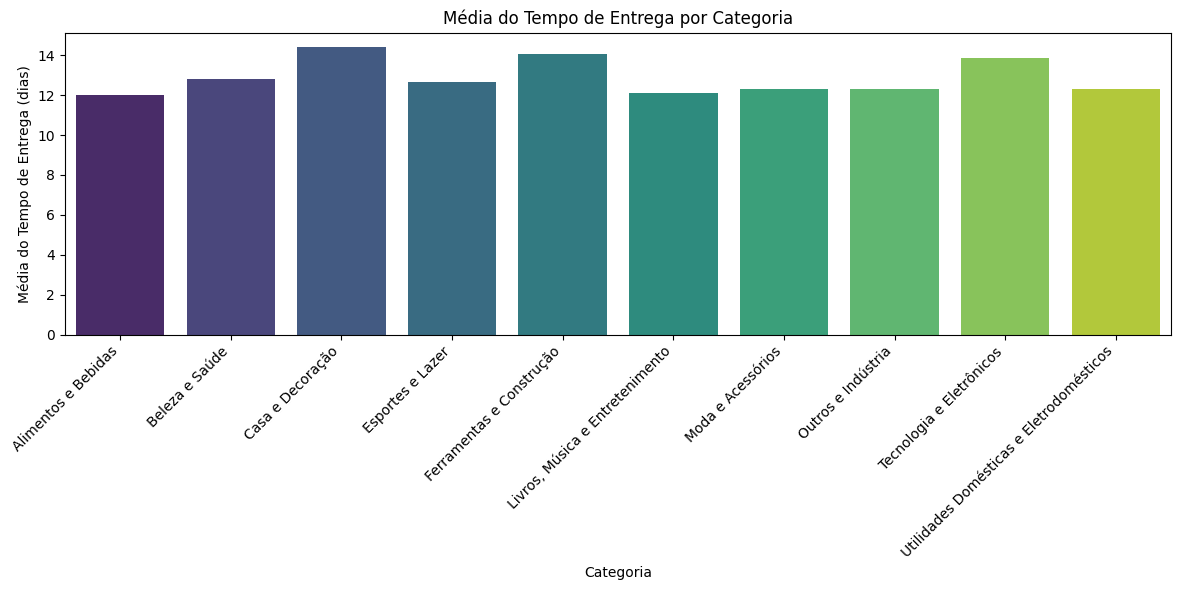

In [246]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular a média do tempo de entrega por categoria
media_tempo_entrega = df.groupby('categoria_principal')['delivery_time (days)'].mean()

# Configuração do gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=media_tempo_entrega.index, y=media_tempo_entrega.values, palette="viridis")

# Personalizar o gráfico
plt.xticks(rotation=45, ha='right')
plt.xlabel('Categoria')
plt.ylabel('Média do Tempo de Entrega (dias)')
plt.title('Média do Tempo de Entrega por Categoria')
plt.tight_layout()

# Exibir o gráfico
plt.show()


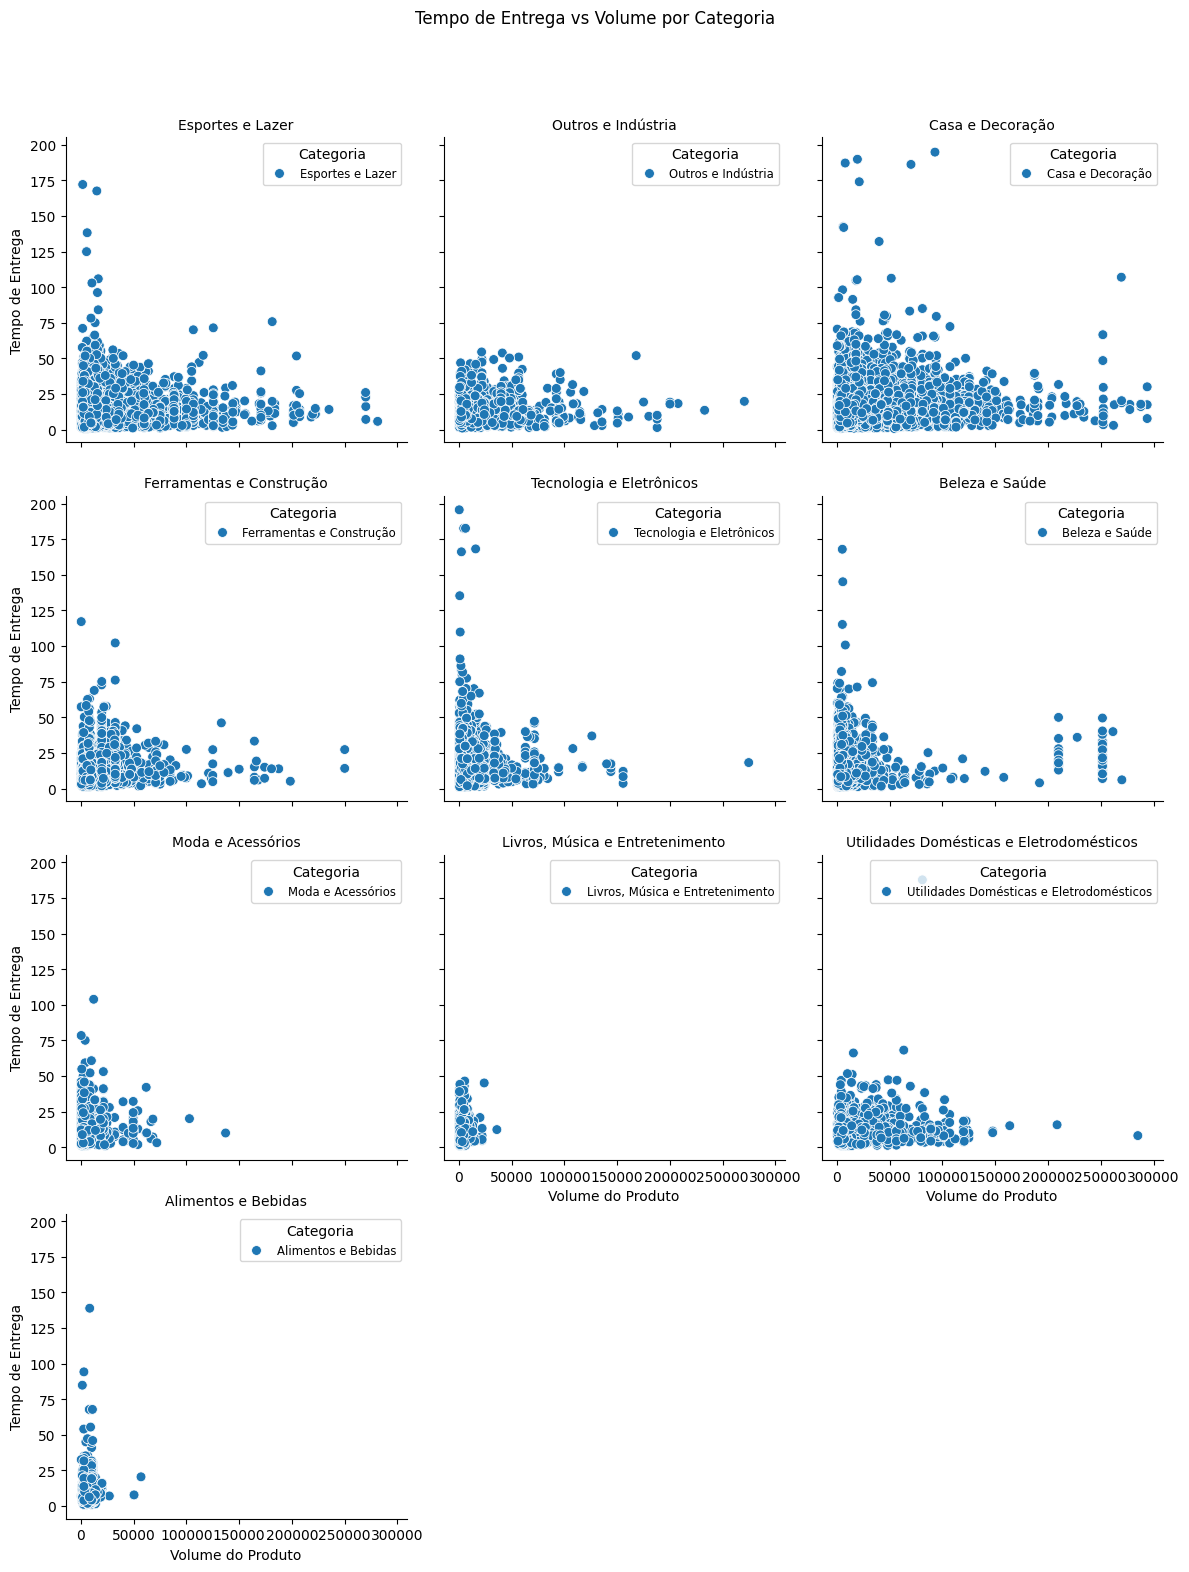

In [247]:
# Configurando o grid de gráficos por categoria
g = sns.FacetGrid(
    df, 
    col='categoria_principal', 
    col_wrap=3, 
    height=4, 
    sharex=True, 
    sharey=True, 
    palette='husl'  # Define uma paleta de cores vívida para cada categoria
)
g.map_dataframe(sns.scatterplot, 'product_volume', 'delivery_time (days)', hue='categoria_principal', s=50)

# Ajustes finais de título e eixos
g.set_axis_labels("Volume do Produto", "Tempo de Entrega")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Tempo de Entrega vs Volume por Categoria")

# Ajuste das legendas
for ax in g.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles=handles, labels=labels, title="Categoria", loc="upper right", fontsize='small', frameon=True)

plt.show()


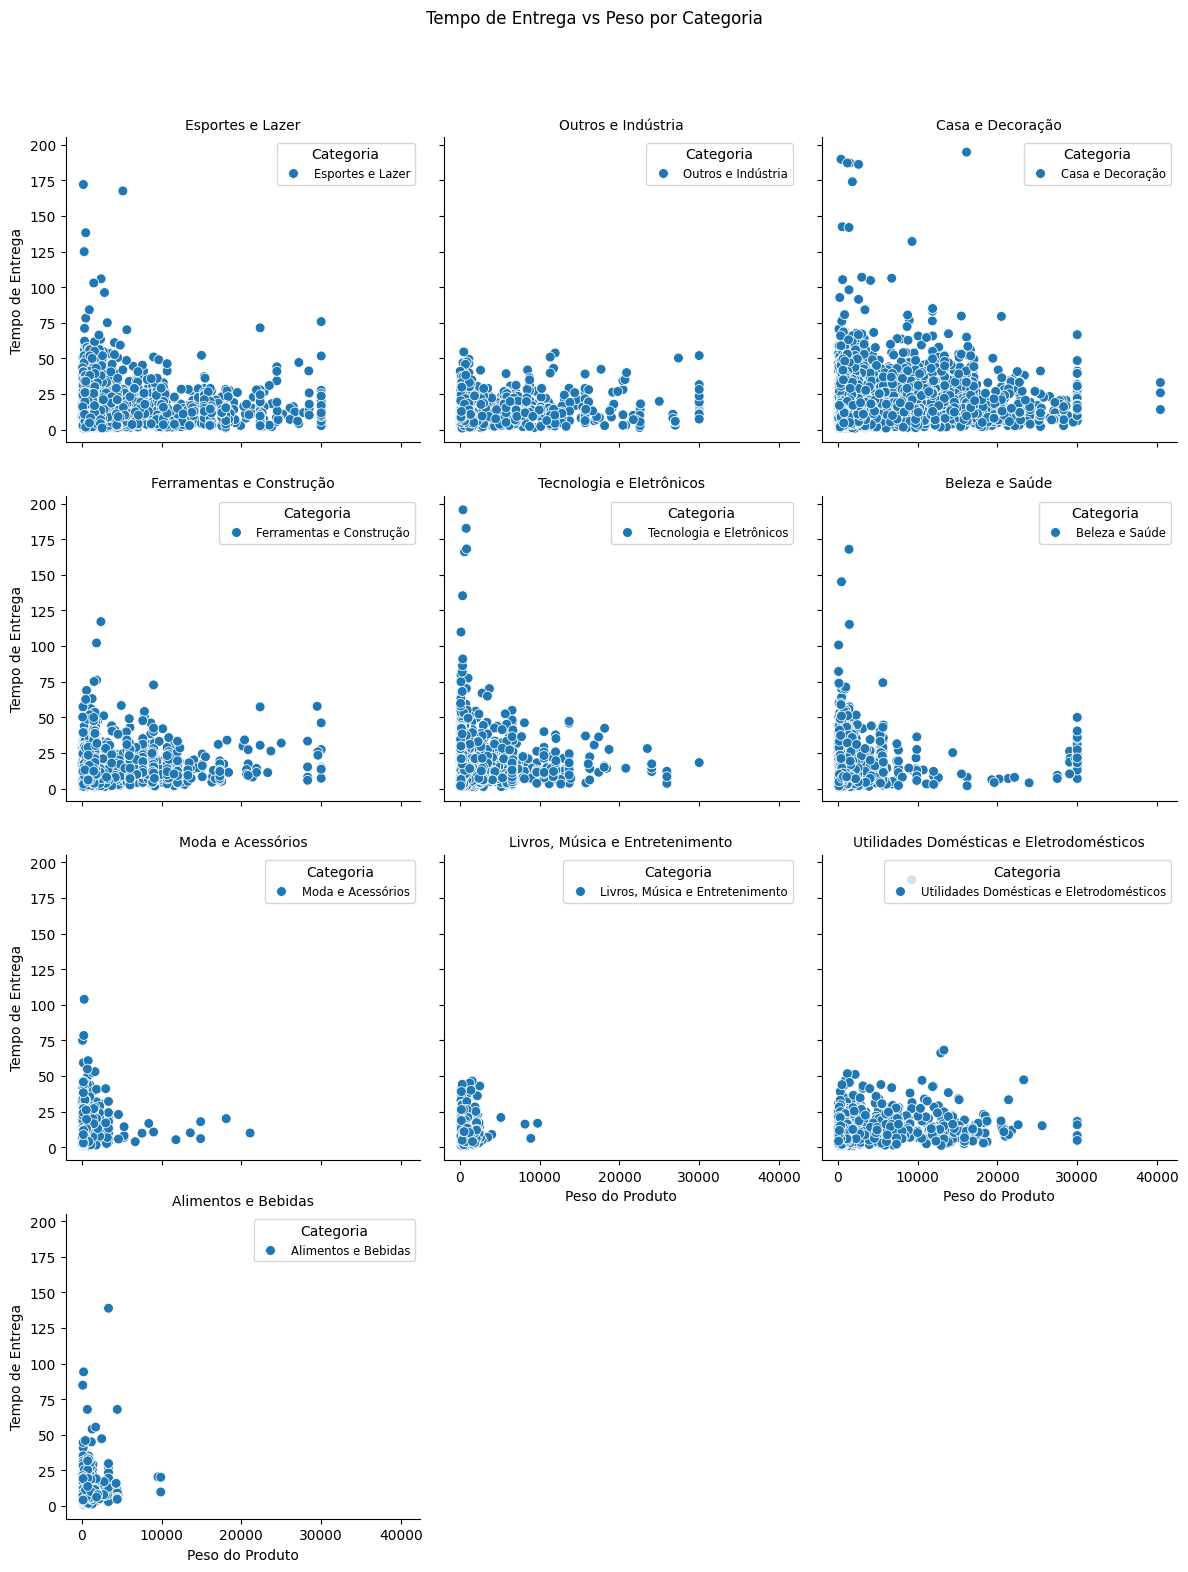

In [248]:
# Configurando o grid de gráficos por categoria
g = sns.FacetGrid(
    df, 
    col='categoria_principal', 
    col_wrap=3, 
    height=4, 
    sharex=True, 
    sharey=True, 
    palette='husl'  # Define uma paleta de cores vívida para cada categoria
)
g.map_dataframe(sns.scatterplot, 'product_weight_g', 'delivery_time (days)', hue='categoria_principal', s=50)

# Ajustes finais de título e eixos
g.set_axis_labels("Peso do Produto", "Tempo de Entrega")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Tempo de Entrega vs Peso por Categoria")

# Ajuste das legendas
for ax in g.axes.flat:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles=handles, labels=labels, title="Categoria", loc="upper right", fontsize='small', frameon=True)

plt.show()


C:\Users\ferna\AppData\Local\Temp\ipykernel_41924\2737846865.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_sellers, x='geolocation_state_seller', y='Quantidade de Vendedores', palette='viridis')


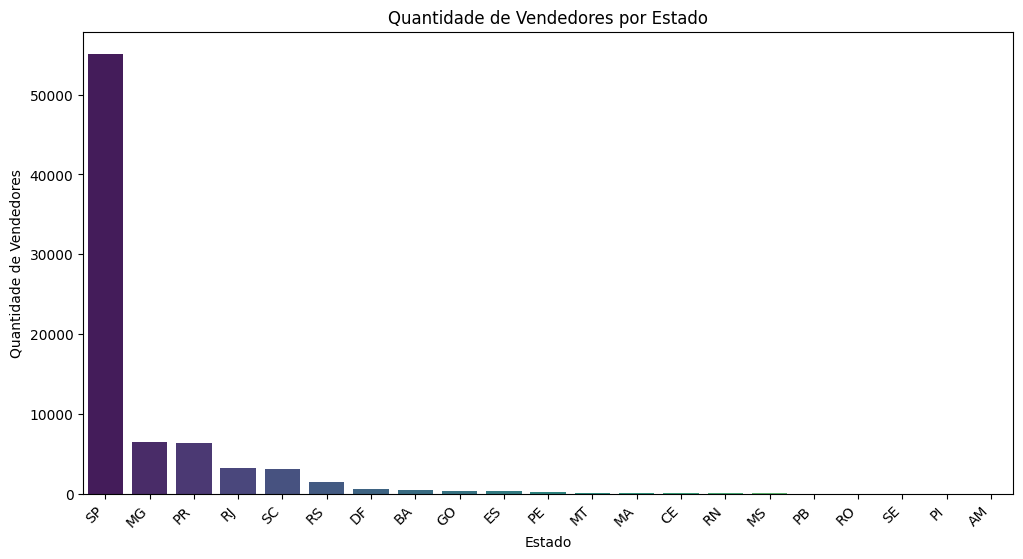

In [249]:
# Contando o número de sellers por cidade
contagem_sellers = df['geolocation_state_seller'].value_counts().reset_index()
contagem_sellers.columns = ['geolocation_state_seller', 'Quantidade de Vendedores']

# Configurando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=contagem_sellers, x='geolocation_state_seller', y='Quantidade de Vendedores', palette='viridis')

# Ajustes finais
plt.title("Quantidade de Vendedores por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Vendedores")
plt.xticks(rotation=45, ha='right')  # Rotaciona os nomes das cidades para facilitar a leitura
plt.show()


C:\Users\ferna\AppData\Local\Temp\ipykernel_41924\3774296055.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_sellers, x='geolocation_state_customer', y='Quantidade de Clientes', palette='viridis')


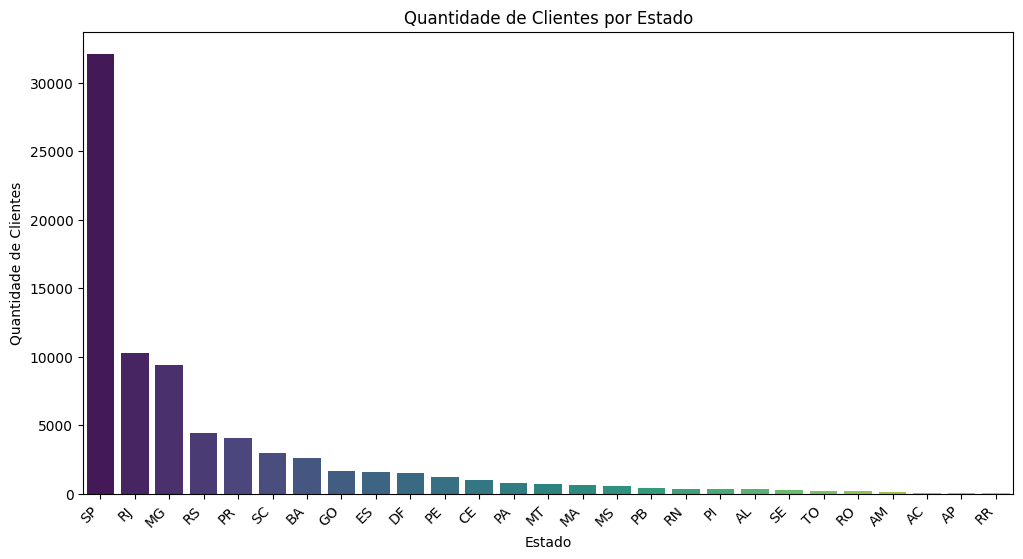

In [250]:
# Contando o número de sellers por cidade
contagem_sellers = df['geolocation_state_customer'].value_counts().reset_index()
contagem_sellers.columns = ['geolocation_state_customer', 'Quantidade de Clientes']

# Configurando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=contagem_sellers, x='geolocation_state_customer', y='Quantidade de Clientes', palette='viridis')

# Ajustes finais
plt.title("Quantidade de Clientes por Estado")
plt.xlabel("Estado")
plt.ylabel("Quantidade de Clientes")
plt.xticks(rotation=45, ha='right')  # Rotaciona os nomes das cidades para facilitar a leitura
plt.show()

C:\Users\ferna\AppData\Local\Temp\ipykernel_41924\1719946908.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_sellers, x='Cidade', y='Quantidade de Sellers', palette='viridis')


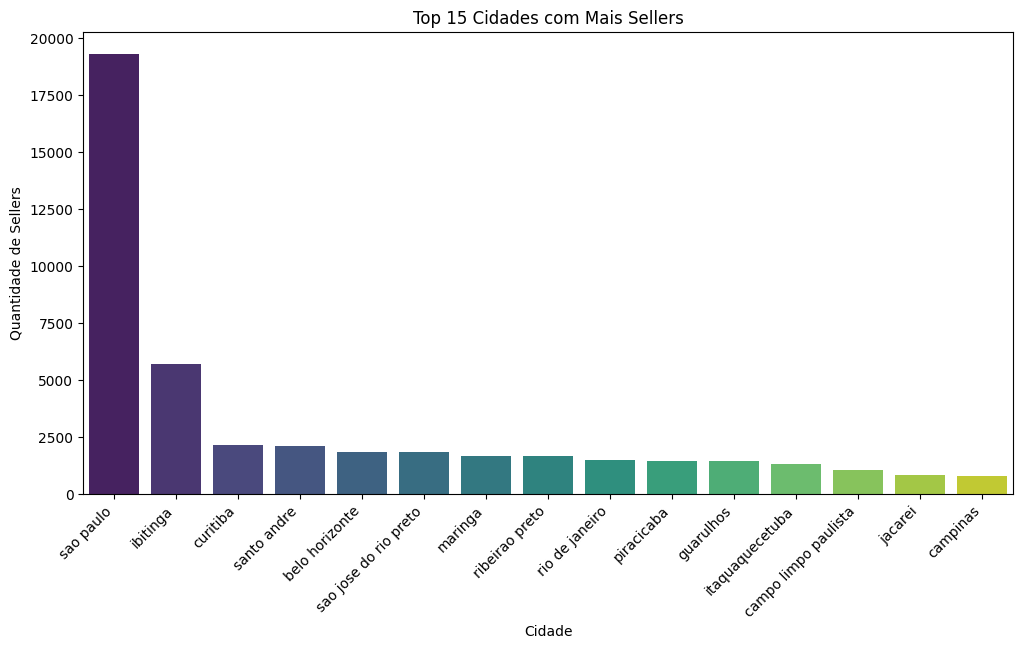

In [251]:
# Contando o número de sellers por cidade e selecionando as 15 cidades com mais sellers
contagem_sellers = df['geolocation_city_seller'].value_counts().head(15).reset_index()
contagem_sellers.columns = ['Cidade', 'Quantidade de Sellers']

# Configurando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=contagem_sellers, x='Cidade', y='Quantidade de Sellers', palette='viridis')

# Ajustes finais
plt.title("Top 15 Cidades com Mais Sellers")
plt.xlabel("Cidade")
plt.ylabel("Quantidade de Sellers")
plt.xticks(rotation=45, ha='right')  # Rotaciona os nomes das cidades para facilitar a leitura
plt.show()


C:\Users\ferna\AppData\Local\Temp\ipykernel_41924\3620775962.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contagem_sellers, x='Cidade', y='Quantidade de Clientes', palette='viridis')


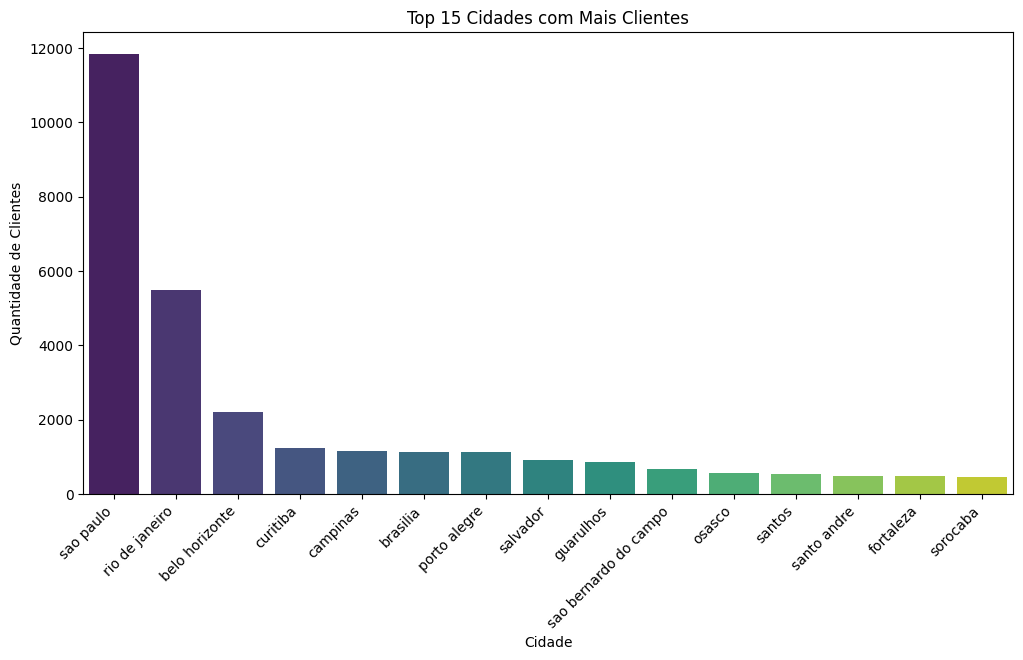

In [252]:
# Contando o número de sellers por cidade e selecionando as 15 cidades com mais sellers
contagem_sellers = df['geolocation_city_customer'].value_counts().head(15).reset_index()
contagem_sellers.columns = ['Cidade', 'Quantidade de Clientes']

# Configurando o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=contagem_sellers, x='Cidade', y='Quantidade de Clientes', palette='viridis')

# Ajustes finais
plt.title("Top 15 Cidades com Mais Clientes")
plt.xlabel("Cidade")
plt.ylabel("Quantidade de Clientes")
plt.xticks(rotation=45, ha='right')  # Rotaciona os nomes das cidades para facilitar a leitura
plt.show()


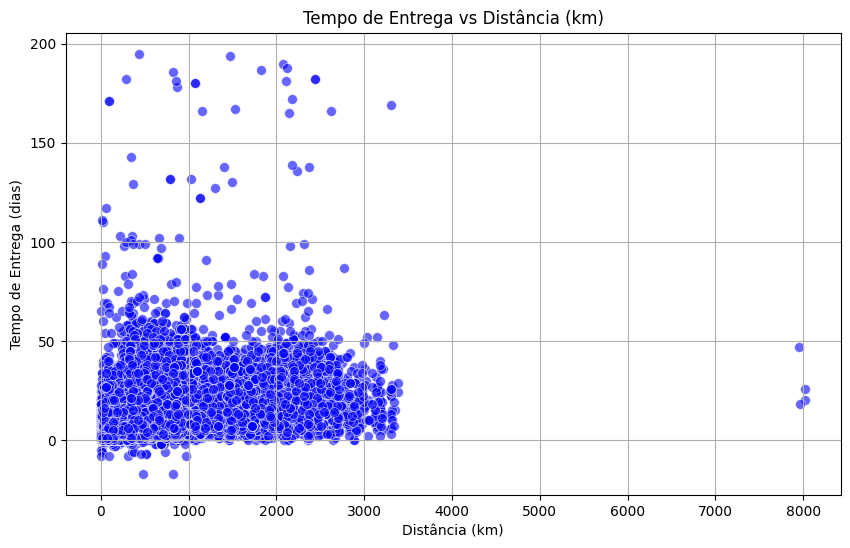

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Criando o scatter plot
sns.scatterplot(data=df, x='distancia_km', y='carrier_to_customer_days', alpha=0.6, s=50, color='b')

# Ajustes finais
plt.title("Tempo de Entrega vs Distância (km)")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (dias)")
plt.grid(True)
plt.show()


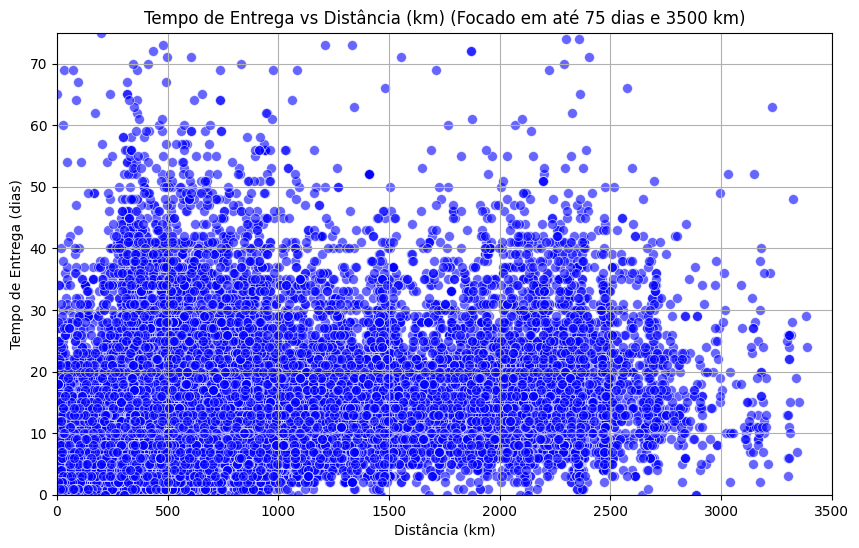

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Criando o scatter plot com limites específicos
sns.scatterplot(data=df, x='distancia_km', y='carrier_to_customer_days', alpha=0.6, s=50, color='b')

# Ajustando os limites dos eixos
plt.xlim(0, 3500)   # Limite para a distância
plt.ylim(0, 75)     # Limite para o tempo de entrega

# Ajustes finais
plt.title("Tempo de Entrega vs Distância (km) (Focado em até 75 dias e 3500 km)")
plt.xlabel("Distância (km)")
plt.ylabel("Tempo de Entrega (dias)")
plt.grid(True)
plt.show()


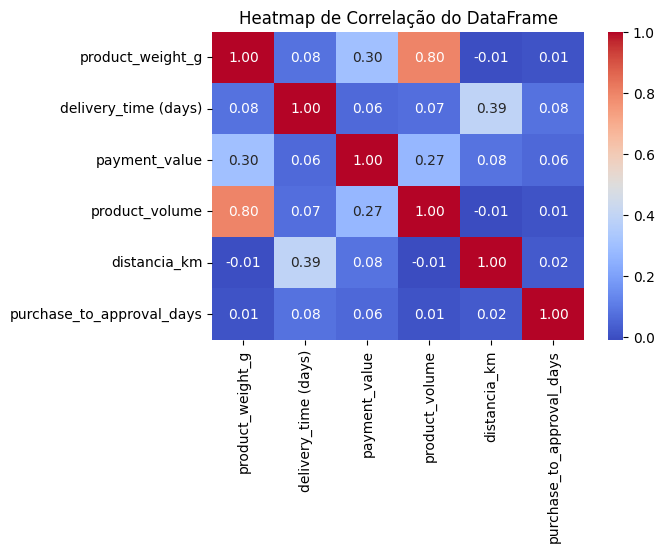

In [255]:
# Carregar o arquivo CSV
df_new = pd.read_csv('base_atualizada.csv')

# Remover as colunas indesejadas
df_new = df_new.drop(columns=['freight_value','price', 'order_item_id', 'seller_zip_code_prefix', 'delivery_time_model (days)', 'customer_zip_code_prefix', 'approval_to_carrier_days','carrier_to_customer_days'])

# Selecionar apenas as colunas numéricas
df_numerical = df_new.select_dtypes(include=[np.number])

correlation_matrix = df_numerical.corr()

# Criando o heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap de Correlação do DataFrame")
plt.show()

C:\Users\ferna\AppData\Local\Temp\ipykernel_41924\3499646669.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=media_tempo_entrega, x='Cidade', y='Tempo Médio de Entrega', palette='coolwarm', order=media_tempo_entrega.sort_values('Tempo Médio de Entrega', ascending=False)['Cidade'])


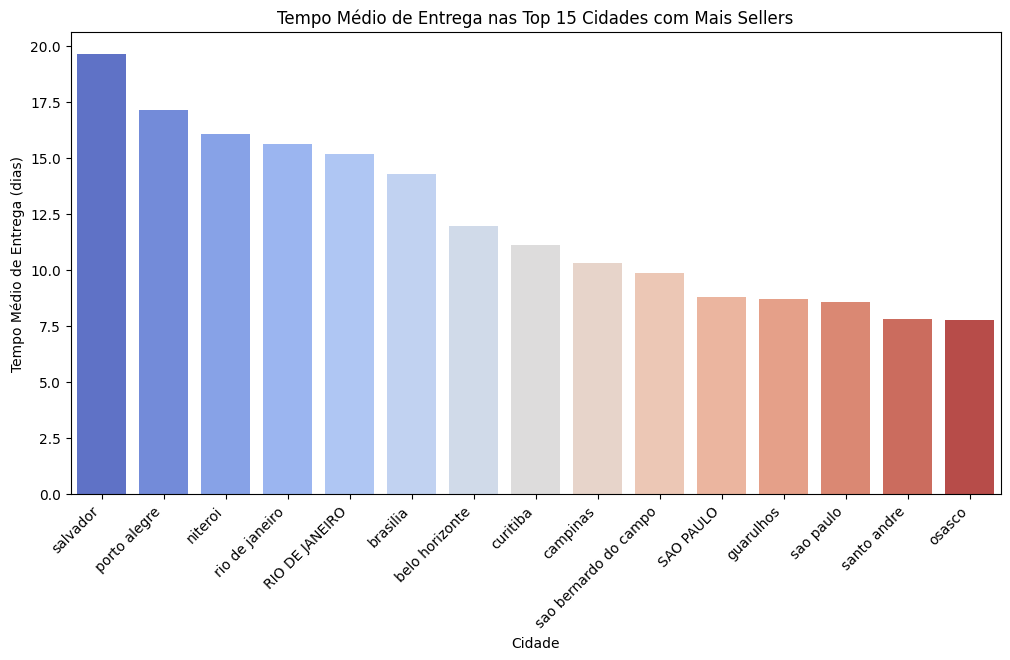

In [256]:
# Passo 1: Contar o número de sellers por cidade e selecionar as 15 cidades com mais sellers
top_15_cidades = df_new['customer_city'].value_counts().head(15).index

# Passo 2: Filtrar o DataFrame para manter apenas as cidades no top 15
df_top_15 = df_new[df_new['customer_city'].isin(top_15_cidades)]

# Passo 3: Calcular o tempo médio de entrega para cada uma das 15 cidades
media_tempo_entrega = df_top_15.groupby('customer_city')['delivery_time (days)'].mean().reset_index()
media_tempo_entrega.columns = ['Cidade', 'Tempo Médio de Entrega']

# Passo 4: Ordenar as cidades por tempo médio de entrega e criar o gráfico de barras
plt.figure(figsize=(12, 6))
sns.barplot(data=media_tempo_entrega, x='Cidade', y='Tempo Médio de Entrega', palette='coolwarm', order=media_tempo_entrega.sort_values('Tempo Médio de Entrega', ascending=False)['Cidade'])

# Ajustes finais
plt.title("Tempo Médio de Entrega nas Top 15 Cidades com Mais Sellers")
plt.xlabel("Cidade")
plt.ylabel("Tempo Médio de Entrega (dias)")
plt.xticks(rotation=45, ha='right')
plt.show()
